# 假设检验

参数估计告诉我们“样本中看到的数值是多少”。假设检验进一步问：这些样本差异是否足够大，大到不太可能只是抽样波动造成的？

本章继续直接使用现成数据，并把检验放在具体问题中完成。每个检验都按同一顺序展开：先提出问题，再整理检验需要的数据，查看处理结果，最后计算检验统计量和 p 值。

## 本章知识点

1. 假设检验的基本步骤：原假设、备择假设、显著性水平、p 值和结论。
2. 单样本 t 检验：检验一组样本均值是否等于给定值。
3. 双样本 t 检验：比较两组样本均值是否相同。
4. 卡方检验：检验两个分类变量是否独立。
5. 方差分析：比较三组或更多组的均值是否相同。
6. 结果解释：把 p 值判断转化为研究问题中的结论。

**本章使用的数据**

本章使用的数据放在工作目录下的 `data` 文件夹中。读取时用相对路径，例如 `data/titanic.csv`。

- `data/titanic.csv`：泰坦尼克号乘客数据。一行是一名乘客，包含生存情况、舱位、性别、年龄、票价、登船港口等变量，用于单样本 t 检验、双样本 t 检验和卡方检验。[下载](data/titanic.csv)
- `data/tips.csv`：餐厅消费和小费数据。一行是一桌顾客的消费记录，包含账单金额、小费、性别、是否吸烟、星期、用餐时段和人数，用于补充练习和不显著案例。[下载](data/tips.csv)

::: {.callout-important}
### 注意
1. 本章默认数据文件放在当前章节 notebook 同级目录下的 `data` 文件夹中。
2. 假设检验前要先检查变量类型：t 检验和方差分析关注连续变量均值，卡方检验关注分类变量之间的关系。
3. 本章的缺失值处理以“删除当前分析变量的缺失值”为主。
:::

## 准备工作

前面已经学过 pandas、seaborn 和常规绘图设置，这里不再重复解释。下面只列出本章新增或重点使用的统计检验函数。

**本章新增函数**

- `stats.ttest_1samp(a, popmean)`：单样本 t 检验，检验一组样本的均值是否等于给定值。
- `stats.ttest_ind(a, b, equal_var=False)`：两独立样本 t 检验；`equal_var=False` 表示使用 Welch t 检验。
- `chi2_contingency(table)`：卡方独立性检验，输入列联表。
- `ols("y ~ C(group)", data=数据).fit()`：用公式建立一元方差分析所需的模型。
- `sm.stats.anova_lm(model, typ=1)`：根据模型生成方差分析表。

In [24]:
# 准备本章需要的包和数据
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.formula.api import ols

sns.set_theme()
plt.rcParams["font.sans-serif"] = ["Hiragino Sans GB", "Microsoft YaHei", "WenQuanYi Micro Hei"]
plt.rcParams["axes.unicode_minus"] = False
%config InlineBackend.figure_formats = ["svg"]

titanic = pd.read_csv("data/titanic.csv")
tips = pd.read_csv("data/tips.csv")

先看本章会用到的变量。这里只是确认列名和取值长什么样，不展开 pandas 操作。

In [25]:
# 查看titanic中本章会用到的变量
titanic[["survived", "alive", "pclass", "class", "sex", "age", "fare", "embark_town"]].head()

,survived,alive,pclass,class,sex,age,fare,embark_town
0,0,no,3,Third,male,22.0,7.2500,Southampton
1,1,yes,1,First,female,38.0,71.2833,Cherbourg
2,1,yes,3,Third,female,26.0,7.9250,Southampton
3,1,yes,1,First,female,35.0,53.1000,Southampton
4,0,no,3,Third,male,35.0,8.0500,Southampton


In [26]:
# 查看tips中练习和补充案例会用到的变量
tips[["total_bill", "tip", "sex", "smoker", "day", "time", "size"]].head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 假设检验的统一步骤

无论使用哪一种检验，基本步骤都类似：

1. 写出原假设 $H_0$ 和备择假设 $H_1$。
2. 选择显著性水平，例如 $\alpha=0.05$。
3. 根据变量类型和研究问题选择检验方法。
4. 整理检验所需的数据，并展示处理结果。
5. 计算检验统计量和 p 值。
6. 如果 $p < \alpha$，拒绝原假设；否则不拒绝原假设。
7. 用研究问题本身的语言写结论。

注意：“不拒绝原假设”不等于“证明原假设一定正确”，而是说当前样本没有给出足够强的反对证据。

快速对应关系：

1. 单样本 t 检验：问一组连续变量的均值是否等于某个给定值。
2. 双样本 t 检验：问两组连续变量的均值是否相同。
3. 卡方检验：问两个分类变量是否独立，或者说有没有统计上的关联。
4. 方差分析：问三组或更多组连续变量的均值是否相同。

## 单样本 t 检验

问题：泰坦尼克号乘客的平均年龄是否显著不同于 30 岁？

- 原假设：$H_0: \mu = 30$
- 备择假设：$H_1: \mu \neq 30$

这里的 `age` 是连续变量，检验对象是一个样本均值和给定值 30 的差异。

**本节新增函数和参数**

- `stats.ttest_1samp(a, popmean)`：单样本 t 检验。
- `a`：要检验的一组样本数据。
- `popmean`：原假设中的总体均值。

**第 1 步：取出检验需要的数据。**

我们只需要年龄这一列，并删除年龄缺失的记录。下面展示前几行，用来确认得到的是一列干净的年龄数据。

In [27]:
# 取出年龄变量并删除缺失值
age = titanic["age"].dropna()
age.head()

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: age, dtype: float64

**第 2 步：查看样本概况。**

重点看样本数、平均年龄和标准差。样本均值会和原假设中的 30 岁比较。

In [28]:
# 查看年龄样本的描述统计
pd.Series(
    {
        "样本数": age.count(),
        "平均年龄": age.mean(),
        "标准差": age.std(ddof=1),
        "最小值": age.min(),
        "最大值": age.max(),
    }
).round(3)

样本数     714.000
平均年龄     29.699
标准差      14.526
最小值       0.420
最大值      80.000
dtype: float64

**第 3 步：画图。**

直方图用来查看年龄分布。橙色虚线是原假设中的 30 岁，绿色实线是样本均值。两条线很接近，直观上已经能看出差异不会很大。

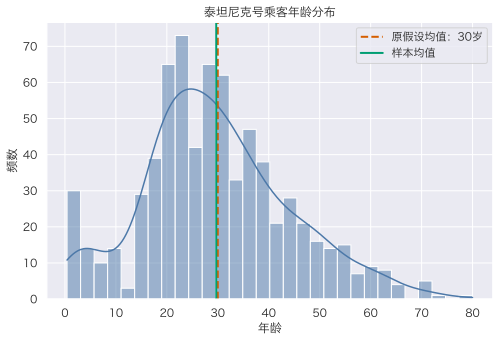

In [29]:
# 绘制年龄分布，并标出原假设均值和样本均值
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(age, bins=30, kde=True, color="#4C78A8", ax=ax)
ax.axvline(30, color="#D55E00", linestyle="--", linewidth=2, label="原假设均值：30岁")
ax.axvline(age.mean(), color="#009E73", linestyle="-", linewidth=2, label="样本均值")

ax.set_title("泰坦尼克号乘客年龄分布")
ax.set_xlabel("年龄")
ax.set_ylabel("频数")
ax.legend()
plt.show()

**第 4 步：做单样本 t 检验。**

`pvalue` 是判断是否拒绝原假设的关键结果。

In [30]:
# 检验平均年龄是否等于30岁
age_t = stats.ttest_1samp(age, popmean=30)  # popmean是原假设中的总体均值

print(f"样本平均年龄: {age.mean():.2f}")
print(f"t统计量: {age_t.statistic:.3f}")
print(f"p值: {age_t.pvalue:.3f}")

样本平均年龄: 29.70
t统计量: -0.553
p值: 0.580


结论：p 值大于 0.05，因此不能拒绝“平均年龄等于 30 岁”的原假设。换成研究问题的语言：在这份有年龄记录的样本中，没有足够证据说明乘客平均年龄显著不同于 30 岁。

### 补充：一个显著的单样本 t 检验

上面的年龄例子没有拒绝原假设。为了看到“拒绝原假设”的情况，再看一个小费例子：餐厅顾客的平均小费是否显著不同于 2.5 美元？

- 原假设：$H_0: \mu = 2.5$
- 备择假设：$H_1: \mu \neq 2.5$

这里仍然使用 `stats.ttest_1samp(a, popmean)`。

**第 1 步：取出小费数据并查看样本概况。**

这一步看样本均值是否明显偏离 2.5 美元。

In [31]:
# 取出小费变量并查看描述统计
tip = tips["tip"].dropna()

pd.Series(
    {
        "样本数": tip.count(),
        "平均小费": tip.mean(),
        "标准差": tip.std(ddof=1),
        "最小值": tip.min(),
        "最大值": tip.max(),
    }
).round(3)

样本数     244.000
平均小费      2.998
标准差       1.384
最小值       1.000
最大值      10.000
dtype: float64

**第 2 步：做单样本 t 检验。**

这里把 `popmean` 设为 2.5。

In [32]:
# 检验平均小费是否等于2.5美元
tip_t = stats.ttest_1samp(tip, popmean=2.5)  # popmean是原假设中的总体均值

print(f"样本平均小费: {tip.mean():.2f}")
print(f"t统计量: {tip_t.statistic:.3f}")
print(f"p值: {tip_t.pvalue:.3g}")

样本平均小费: 3.00
t统计量: 5.625
p值: 5.08e-08


结论：p 值远小于 0.05，因此拒绝“平均小费等于 2.5 美元”的原假设。换成研究问题的语言：这份样本显示，餐厅顾客的平均小费显著不同于 2.5 美元；从样本均值看，平均小费高于 2.5 美元。

## 双样本 t 检验

问题：一等舱和三等舱乘客的平均年龄是否不同？

- 原假设：$H_0: \mu_{\text{First}} = \mu_{\text{Third}}$
- 备择假设：$H_1: \mu_{\text{First}} \neq \mu_{\text{Third}}$

这里比较的是两个独立样本的均值。由于两组样本方差不一定相同，下面使用 Welch t 检验。

**本节新增函数和参数**

- `stats.ttest_ind(a, b, equal_var=False)`：两独立样本 t 检验。
- `a, b`：要比较的两组样本数据。
- `equal_var=False`：不假设两组总体方差相等，即 Welch t 检验。

**第 1 步：筛选一等舱和三等舱记录。**

下面先展示筛选后的前几行，确认只保留了一等舱和三等舱，并且年龄不是缺失值。

In [33]:
# 筛选一等舱和三等舱中年龄不缺失的记录
age_by_class = titanic.loc[
    titanic["pclass"].isin([1, 3]),
    ["pclass", "class", "age"],
].dropna(subset=["age"])

age_by_class.head()

,pclass,class,age
0,3,Third,22.0
1,1,First,38.0
2,3,Third,26.0
3,1,First,35.0
4,3,Third,35.0


**第 2 步：查看两组样本概况。**

重点看两组的样本数、平均年龄和标准差。只有先看分组结果，后面的检验才有解释对象。

In [34]:
# 按舱位汇总年龄样本
age_by_class.groupby(["pclass", "class"])["age"].agg(
    样本数="count",
    平均年龄="mean",
    标准差="std",
).round(3)

,,样本数,平均年龄,标准差
pclass,class,,,
1,First,186,38.233,14.803
3,Third,355,25.141,12.495


**第 3 步：画图比较两组分布。**

箱形图能看到两组中位数和整体分布位置。一等舱年龄整体更高。

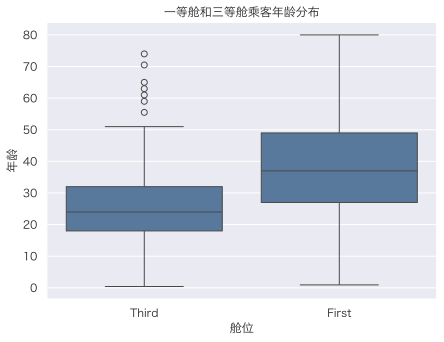

In [35]:
# 用箱形图比较一等舱和三等舱乘客年龄分布
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(data=age_by_class, x="class", y="age", color="#4C78A8", ax=ax)
ax.set_title("一等舱和三等舱乘客年龄分布")
ax.set_xlabel("舱位")
ax.set_ylabel("年龄")
plt.show()

**第 4 步：做 Welch 双样本 t 检验。**

先把两组年龄分别取出，再放进 `stats.ttest_ind()`。

In [36]:
# 对一等舱和三等舱平均年龄进行Welch双样本t检验
age_first = age_by_class.loc[age_by_class["pclass"] == 1, "age"]
age_third = age_by_class.loc[age_by_class["pclass"] == 3, "age"]

class_age_t = stats.ttest_ind(age_first, age_third, equal_var=False)  # equal_var=False表示Welch t检验

print(f"一等舱平均年龄: {age_first.mean():.2f}")
print(f"三等舱平均年龄: {age_third.mean():.2f}")
print(f"t统计量: {class_age_t.statistic:.3f}")
print(f"p值: {class_age_t.pvalue:.3g}")

一等舱平均年龄: 38.23
三等舱平均年龄: 25.14
t统计量: 10.293
p值: 1.07e-21


结论：p 值远小于 0.05，因此拒绝“两组平均年龄相同”的原假设。换成研究问题的语言：这份样本显示，一等舱和三等舱乘客的平均年龄存在显著差异；从样本均值看，一等舱乘客年龄更高。

## 卡方检验

问题：乘客的生存情况是否与性别有关？

- 原假设：$H_0$：生存情况与性别相互独立。
- 备择假设：$H_1$：生存情况与性别不独立。

这里 `survived` 和 `sex` 都是分类变量，所以使用卡方独立性检验。

**本节新增函数和结果**

- `chi2_contingency(table)`：卡方独立性检验。
- `table`：列联表。
- 返回值 `chi2, p, dof, expected`：分别是卡方统计量、p 值、自由度和期望频数。

**第 1 步：构造列联表。**

列联表展示两个分类变量的交叉频数。这里先看观察频数：女性和男性分别有多少人生还、多少人未生还。

In [37]:
# 构造生存情况和性别的列联表
survival_sex_table = pd.crosstab(titanic["survived"], titanic["sex"])
survival_sex_table

sex,female,male
survived,,
0,81,468
1,233,109


**第 2 步：画计数图。**

图形和列联表表达的是同一件事：不同性别中，生还和未生还人数的分布是否明显不同。

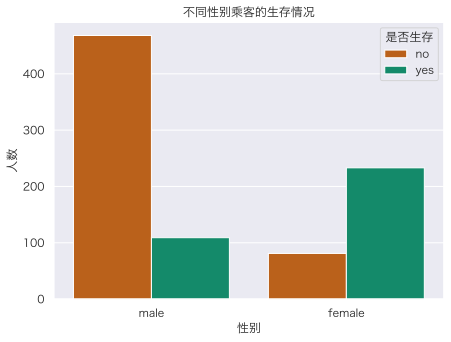

In [38]:
# 用计数图展示不同性别乘客的生存情况
fig, ax = plt.subplots(figsize=(7, 5))

sns.countplot(data=titanic, x="sex", hue="alive", palette=["#D55E00", "#009E73"], ax=ax)
ax.set_title("不同性别乘客的生存情况")
ax.set_xlabel("性别")
ax.set_ylabel("人数")
ax.legend(title="是否生存")
plt.show()

**第 3 步：做卡方独立性检验。**

输出中重点看 p 值。期望频数表示：如果“性别”和“生存情况”真的独立，各格子大约应该是多少。

In [39]:
# 对生存情况和性别进行卡方独立性检验
chi2, p, dof, expected = chi2_contingency(survival_sex_table)  # expected是原假设下的期望频数

print(f"卡方统计量: {chi2:.3f}")
print(f"p值: {p:.3g}")
print(f"自由度: {dof}")
print("期望频数：")
print(pd.DataFrame(expected, index=survival_sex_table.index, columns=survival_sex_table.columns).round(2))

卡方统计量: 260.717
p值: 1.2e-58
自由度: 1
期望频数：
sex       female    male
survived                
0         193.47  355.53
1         120.53  221.47


结论：p 值远小于 0.05，因此拒绝“生存情况与性别独立”的原假设。换成研究问题的语言：这份样本显示，乘客生存情况与性别存在显著关联。

## 方差分析

问题：不同登船港口乘客的平均票价是否相同？

- 原假设：$H_0$：不同登船港口乘客的总体平均票价相同。
- 备择假设：$H_1$：至少有一个登船港口的总体平均票价不同。

这里 `embark_town` 是分类变量，有三个类别；`fare` 是连续变量。因此使用一元方差分析。这个例子会得到显著结果。

**本节新增函数和参数**

- `ols("y ~ C(group)", data=数据).fit()`：建立一元方差分析所需的模型。
- `C(group)`：在公式中把变量明确作为分类变量处理。
- `sm.stats.anova_lm(model, typ=1)`：根据模型生成 ANOVA 表。
- `typ=1`：使用 I 型平方和；本章一元方差分析中结果容易理解。

**第 1 步：整理票价和登船港口。**

下面先删除这两个变量中的缺失值，再展示前几行，确认每行都有登船港口和票价。

In [40]:
# 整理方差分析需要的登船港口和票价数据
fare_by_port = titanic[["embark_town", "fare"]].dropna()
fare_by_port.head()

,embark_town,fare
0,Southampton,7.2500
1,Cherbourg,71.2833
2,Southampton,7.9250
3,Southampton,53.1000
4,Southampton,8.0500


**第 2 步：查看各组样本概况。**

重点看每个港口的样本数和平均票价。平均票价差异越大，越可能得到显著结果；但最终仍要看检验。

In [41]:
# 按登船港口汇总票价
fare_by_port.groupby("embark_town")["fare"].agg(
    样本数="count",
    平均票价="mean",
    标准差="std",
).round(3)

,样本数,平均票价,标准差
embark_town,,,
Cherbourg,168,59.954,83.913
Queenstown,77,13.276,14.188
Southampton,644,27.080,35.888


**第 3 步：画图比较各组分布。**

箱形图可以看到不同港口票价分布差异很明显，尤其是 Cherbourg 的票价整体更高。

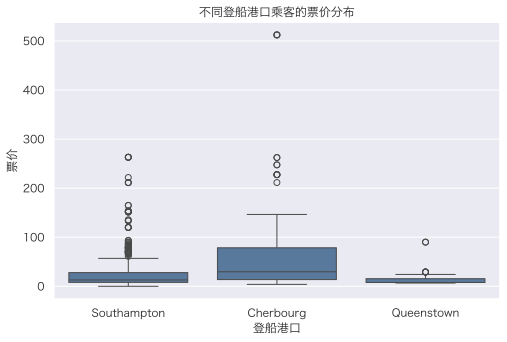

In [42]:
# 用箱形图比较不同登船港口乘客的票价分布
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=fare_by_port, x="embark_town", y="fare", color="#4C78A8", ax=ax)
ax.set_title("不同登船港口乘客的票价分布")
ax.set_xlabel("登船港口")
ax.set_ylabel("票价")
plt.show()

**第 4 步：做一元方差分析。**

ANOVA 表中，重点看 `C(embark_town)` 这一行的 `PR(>F)`，它就是 p 值。

In [43]:
# 对不同登船港口的平均票价进行一元方差分析
fare_anova_model = ols("fare ~ C(embark_town)", data=fare_by_port).fit()  # C()表示把登船港口作为分类变量
fare_anova_results = sm.stats.anova_lm(fare_anova_model, typ=1)  # 生成方差分析表
fare_anova_results.round(3)

,df,sum_sq,mean_sq,F,PR(>F)
C(embark_town),2.0,173857.948,86928.974,38.14,0.0
Residual,886.0,2019361.690,2279.189,NaN,NaN


结论：`C(embark_town)` 这一行的 p 值远小于 0.05，因此拒绝“不同登船港口平均票价相同”的原假设。换成研究问题的语言：这份样本显示，不同登船港口乘客的平均票价存在显著差异。

### 补充：一个不显著的方差分析

显著结果说明样本差异足够大，但并不是所有分组比较都会显著。下面再看餐厅数据中“不同星期的平均小费是否相同”。这里不再介绍新函数，重点是看同一种方法也可能得到不显著结果。

**第 1 步：整理星期和小费数据。**

先展示前几行，确认数据只包含星期和小费。

In [44]:
# 整理不同星期的小费数据
day_tip = tips[["day", "tip"]].dropna()
day_tip.head()

,day,tip
0,Sun,1.01
1,Sun,1.66
2,Sun,3.50
3,Sun,3.31
4,Sun,3.61


**第 2 步：查看各组样本概况。**

不同星期的小费均值有差异，但差异没有前面票价案例那么明显。

In [45]:
# 按星期汇总小费
day_tip_summary = day_tip.groupby("day")["tip"].agg(
    样本数="count",
    平均小费="mean",
    标准差="std",
)
day_tip_summary.round(3)

,样本数,平均小费,标准差
day,,,
Fri,19,2.735,1.020
Sat,87,2.993,1.631
Sun,76,3.255,1.235
Thur,62,2.771,1.240


**第 3 步：做一元方差分析。**

还是看 `C(day)` 这一行的 p 值。

In [46]:
# 对不同星期的平均小费进行一元方差分析
day_anova_model = ols("tip ~ C(day)", data=day_tip).fit()  # C(day)表示把day作为分类变量
day_anova_results = sm.stats.anova_lm(day_anova_model, typ=1)
day_anova_results.round(3)

,df,sum_sq,mean_sq,F,PR(>F)
C(day),3.0,9.526,3.175,1.672,0.174
Residual,240.0,455.687,1.899,NaN,NaN


补充结论：`C(day)` 这一行的 p 值大于 0.05，因此不能拒绝“不同星期平均小费相同”的原假设。这个例子用于说明：方差分析既可能得到显著结果，也可能得到不显著结果。

## 本章小结

1. t 检验和方差分析都关注连续变量的均值差异，区别在于比较对象不同。
2. 单样本 t 检验比较“一组样本均值”和“给定值”。
3. 双样本 t 检验比较“两组样本均值”。如果不想假设两组方差相等，可以使用 Welch t 检验。
4. 方差分析比较“三组或更多组样本均值”。如果拒绝原假设，只能说明至少有一组不同，具体哪几组不同还需要进一步比较。
5. 卡方检验关注两个分类变量是否独立。
6. 写结论时不要只写 p 值，要回到原来的研究问题。

## 综合练习

继续使用 `tips` 和 `titanic` 数据。

**练习 1：单样本 t 检验**

使用 `tips["tip"]`，分别检验平均小费是否显著不同于 2.5 美元和 3 美元。比较两个检验的 p 值，并说明为什么一个更容易显著、另一个不显著。

**练习 2：双样本 t 检验**

使用 `tips`，比较男性和女性顾客的平均小费是否不同。要求：

1. 先按 `sex` 计算样本数、均值和标准差。
2. 画箱形图。
3. 使用 Welch t 检验。
4. 用研究问题语言写结论。

**练习 3：卡方检验**

使用 `tips`，检验 `sex` 和 `smoker` 是否相互独立。要求先构造列联表，再做卡方检验。

**练习 4：方差分析**

使用 `tips`，检验不同星期的平均小费是否相同。变量为 `day` 和 `tip`。要求先画箱形图，再做一元方差分析，并和本章中登船港口与票价的显著结果作比较。